# 03 · The model arena

Five contenders, one stratified train/test split, one scaler. We score each on the held-out test set and save the probabilities for notebook 04 to dissect.

| Model | What it tests |
|---|---|
| Logistic regression | linear boundary, fully interpretable baseline |
| Decision tree (depth 5) | non-linear, single tree, raw overfitting |
| Random forest | bagged trees, strong on imbalance |
| XGBoost | gradient boosting, the tabular champion |
| Neural net | Dense+ReLU+Sigmoid, BCE loss, L2 + dropout |

The neural net is trained **twice** — once with no regularisation (watch it overfit) and once with dropout + L2 (watch it recover) — so the overfitting lesson is visible, not just asserted.

> This notebook uses a **random stratified split**. The temporal split that exposes drift is notebook 05 — keeping them separate is the whole point: standard CV will rank these models one way, and time-aware evaluation will rank them differently.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fraud_utils as fu

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid")
ART = fu.ARTIFACTS_DIR
RNG = np.random.default_rng(42)
import models as M
import tensorflow as tf

I0000 00:00:1781285560.279000     750 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1781285561.588890     750 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
df = pd.read_parquet(os.path.join(ART, '02_features.parquet'))

feature_cols = ([c for c in df.columns if c.startswith('V')] +
                ['amount_log', 'amount_z', 'velocity_10m', 'velocity_1h',
                 'tod_sin', 'tod_cos', 'amount_bucket'])
X = df[feature_cols].values
y = df['Class'].values
print('features:', len(feature_cols), '| rows:', len(y),
      '| fraud:', int(y.sum()))

features: 35 | rows: 60200 | fraud: 200


## Split & scale

Stratified split keeps the fraud ratio identical in train and test. The scaler is fit on **train only** — fitting on the full data would leak test information.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)
print('train', X_tr.shape, 'fraud', int(y_tr.sum()))
print('test ', X_te.shape, 'fraud', int(y_te.sum()))

train (45150, 35) fraud 150
test  (15050, 35) fraud 50


## Train the four non-neural models

Each gets class weighting so the rare class isn't ignored. We collect predicted fraud probabilities on the test set.

In [4]:
spw = M.pos_weight(y_tr)
sk_models = M.get_sklearn_models(scale_pos_weight=spw)
scores = {'y_true': y_te}

for name, model in sk_models.items():
    # trees don't need scaling; linear/NN do. Scaling trees is harmless.
    model.fit(X_tr_s, y_tr)
    scores[name] = model.predict_proba(X_te_s)[:, 1]
    print(f'{name:14s} trained')

logreg         trained


tree           trained


random_forest  trained


xgboost        trained


## The neural net, part 1 — no regularisation

A plain MLP with binary cross-entropy. We hold out a validation slice and watch training vs validation loss. With no dropout or L2 on imbalanced data, the gap between the two curves is the visual signature of **overfitting**.

In [5]:
cw = M.class_weight_dict(y_tr)

net_plain = M.build_keras_mlp(X_tr_s.shape[1], l2=0.0, dropout=0.0)
hist_plain = net_plain.fit(
    X_tr_s, y_tr, validation_split=0.2,
    epochs=30, batch_size=512, class_weight=cw, verbose=0)
scores['nn_plain'] = net_plain.predict(X_te_s, verbose=0).ravel()
print('plain NN trained, epochs:', len(hist_plain.history['loss']))

plain NN trained, epochs: 30


## The neural net, part 2 — with dropout + L2

Same architecture, now with `Dropout(0.3)` between layers and an `L2` penalty on the weights. The training and validation curves should track each other far more closely.

In [6]:
net_reg = M.build_keras_mlp(X_tr_s.shape[1], l2=1e-3, dropout=0.3)
hist_reg = net_reg.fit(
    X_tr_s, y_tr, validation_split=0.2,
    epochs=30, batch_size=512, class_weight=cw, verbose=0)
scores['nn_reg'] = net_reg.predict(X_te_s, verbose=0).ravel()
print('regularised NN trained, epochs:', len(hist_reg.history['loss']))

regularised NN trained, epochs: 30


## See the overfitting

Left: the unregularised net — validation loss flattens or rises while training loss keeps falling (memorising). Right: with dropout + L2 the two curves stay together (generalising).

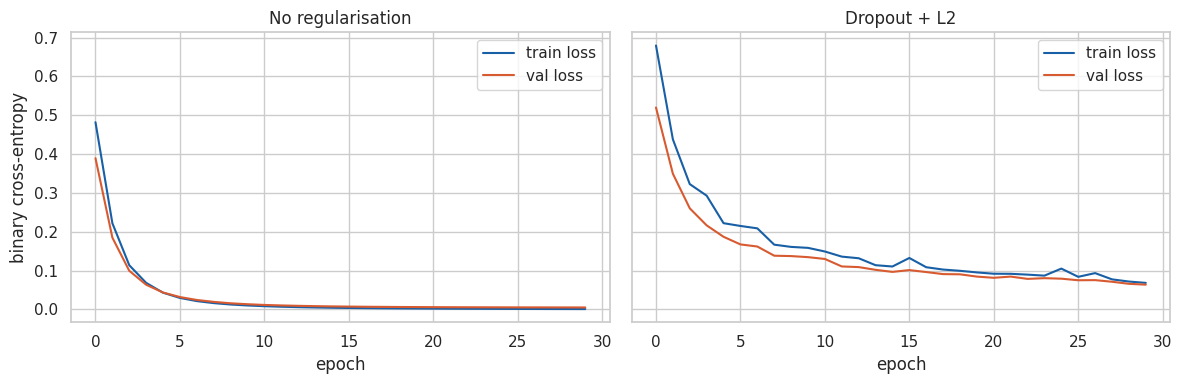

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for a, hist, title in [(ax[0], hist_plain, 'No regularisation'),
                       (ax[1], hist_reg, 'Dropout + L2')]:
    a.plot(hist.history['loss'], label='train loss', color='#185FA5')
    a.plot(hist.history['val_loss'], label='val loss', color='#D85A30')
    a.set_title(title); a.set_xlabel('epoch'); a.legend()
ax[0].set_ylabel('binary cross-entropy')
plt.tight_layout(); plt.show()

## Save every model's test-set scores

Notebook 04 reloads exactly these probabilities, so the evaluation is decoupled from training.

In [8]:
score_df = pd.DataFrame(scores)
out = os.path.join(ART, '03_scores.parquet')
score_df.to_parquet(out, index=False)
print('saved', out, score_df.shape)
score_df.head()

saved /home/claude/fraud-detection-research/artifacts/03_scores.parquet (15050, 7)


,y_true,logreg,tree,random_forest,xgboost,nn_plain,nn_reg
0,0,0.0002,0.0144,0.0000,0.0000,0.0000,0.0000
1,0,0.0024,0.0144,0.0000,0.0000,0.0000,0.0001
2,0,0.0045,0.0144,0.0000,0.0000,0.0000,0.0004
3,0,0.0110,0.0144,0.0009,0.0000,0.0012,0.0002
4,0,0.0036,0.0144,0.0000,0.0000,0.0000,0.0004


### Takeaways
- All five models are trained on an identical split with identical preprocessing — differences from here on are about the *models*, not the setup.
- The two neural-net loss-curve plots make overfitting and its fix concrete.

Next: stop trusting accuracy and actually rank the models.